# Multiplicadores Fiscales Aplicados y Análisis de Sostenibilidad de Deuda

**¿Cuánto se expande el producto por cada dólar de gasto público o se contrae por cada dólar de aumento impositivo a través de paradigmas de identificación competidores (SVAR, Proyecciones Locales y VI Narrativa), y cómo pueden los gestores de deuda soberana proyectar la sostenibilidad de la deuda bajo estrés conjunto de crecimiento, inflación y tasas de interés?**

Esta muestra aplicada de frontera vincula la econometría fiscal estructural con las pruebas de estrés de solvencia soberana para política pública. Implementamos los tres paradigmas canónicos de identificación sobre cuentas fiscales trimestrales unificadas de EE. UU.: el SVAR de Blanchard y Perotti (2002) con elasticidad institucional $\theta = 2.08$, las proyecciones locales narrativas de Romer y Romer (2010), y la proyección local con variables instrumentales externas (LP-IV) de Mertens y Ravn (2013). Posteriormente, alimentamos estos multiplicadores dinámicos en un simulador estocástico de Análisis de Sostenibilidad de Deuda (DSA) soberana que corre 1,000 trayectorias de Monte Carlo bajo innovaciones conjuntas de crecimiento, tasas de interés y déficit primario.

## El método en ecuaciones

**1. SVAR Institucional de Blanchard-Perotti (2002).** Partiendo del VAR en forma reducida para $X_t = (\tau_t, g_t, y_t)'$ (logaritmo de ingresos tributarios reales federales, gasto público y PIB real):
$$ u_t = B \varepsilon_t, \qquad u_t^\tau = \theta u_t^y + \varepsilon_t^\tau, \qquad u_t^g = \varepsilon_t^g, \qquad u_t^y = b_1 u_t^\tau + b_2 u_t^g + \varepsilon_t^y, $$
con la elasticidad institucional $\theta = 2.08$ calculada a partir de los códigos tributarios legales. La perturbación ajustada por el ciclo $\varepsilon_t^\tau = u_t^\tau - \theta u_t^y$ sirve como instrumento para la ecuación del producto.

**2. Proyecciones Locales Narrativas de Romer-Romer (2010).** Las perturbaciones puramente narrativas $z_t$ entran directamente en proyecciones locales aumentadas por rezagos de Jordà (2005):
$$ y_{t+h} - y_{t-1} = \mu_h + m_{\text{RR}}(h) z_t + \sum_{l=1}^p \Gamma_{l, h} X_{t-l} + e_{t+h}, $$
donde $m_{\text{RR}}(h)$ representa la trayectoria del multiplicador por un cambio tributario del 1% del PIB.

**3. LP-IV Narrativa de Mertens-Ravn (2013).** La serie narrativa $z_t$ actúa como instrumento externo para la innovación tributaria endógena $u_t^\tau$:
$$ \hat{m}_{\text{MR}}(h) = \frac{\widehat{\operatorname{Cov}}(y_{t+h} - y_{t-1}, z_t \mid \text{controles})}{\widehat{\operatorname{Cov}}(u_t^\tau, z_t \mid \text{controles})}, \qquad \text{Estadístico } F \text{ de Primera Etapa} = \left(\frac{\hat{\pi}_z}{\text{EE}(\hat{\pi}_z)}\right)^2 > 10. $$

**4. Multiplicadores acumulados y Análisis Estocástico de Sostenibilidad de Deuda (DSA).** Los multiplicadores acumulados promedian las ganancias o pérdidas de producto sobre el horizonte $H$: $\mathcal{M}(H) = \frac{1}{H+1} \sum_{h=0}^H m(h)$. La dinámica de la deuda soberana en relación al PIB sigue la ecuación de bola de nieve:
$$ d_t = \frac{1 + r_t}{1 + g_t} d_{t-1} - pb_t + sf_t \approx d_{t-1} + (r_t - g_t) d_{t-1} - pb_t, $$
donde $(r_t - g_t)$ es el diferencial de bola de nieve y $pb_t$ es el balance primario (% del PIB). A lo largo de $M = 1,000$ trayectorias macroeconómicas simuladas, cuantificamos la probabilidad de rebasar un techo prudencial de deuda $\mathbb{P}(\max_{t \le H} d_t > 80\%)$ y la probabilidad de no estabilización $\mathbb{P}(d_{t+H} > d_t)$.

**Intuición.** Estimar el rendimiento macroeconómico de la política fiscal es complejo debido a la simultaneidad: los ingresos tributarios colapsan automáticamente en las recesiones a través de los estabilizadores automáticos, mientras que las leyes fiscales responden endógenamente al ciclo económico. Blanchard y Perotti resuelven este problema mediante conocimiento institucional de la estructura impositiva; Romer y Romer examinan las minutas legislativas para aislar modificaciones no ligadas al ciclo; y Mertens y Ravn emplean las fechas narrativas como instrumentos para depurar el error de medición. Cuando la expansión fiscal se financia con deuda, estos multiplicadores determinan directamente la solvencia soberana: si el dividendo de crecimiento no compensa el diferencial de bola de nieve $(r - g)$, el coeficiente de deuda sobre PIB entra en una trayectoria inestable. El DSA estocástico traduce las estimaciones econométricas macrofiscales en límites de riesgo de deuda directamente aplicables para ministerios de finanzas y bancos centrales.

Sample: 1950-01-01 to 2006-10-01 (T = 228 quarters)
Mean Federal Tax / GDP = 0.121  ->  1% of GDP tax shock requires 8.3% revenue rise
LP-IV First-Stage F-Statistic: 1072.83
Impact Multipliers (h=0): BP = -0.18 | MR = -0.35 | RR = -0.21
2-Year Multipliers (h=8): BP = -1.21 | MR = -1.62 | RR = -2.76


DSA Simulation Dimensions: (1000, 21)
Baseline Breach Probability (>80% GDP): 19.6%
Probability of Non-Stabilization: 72.3%


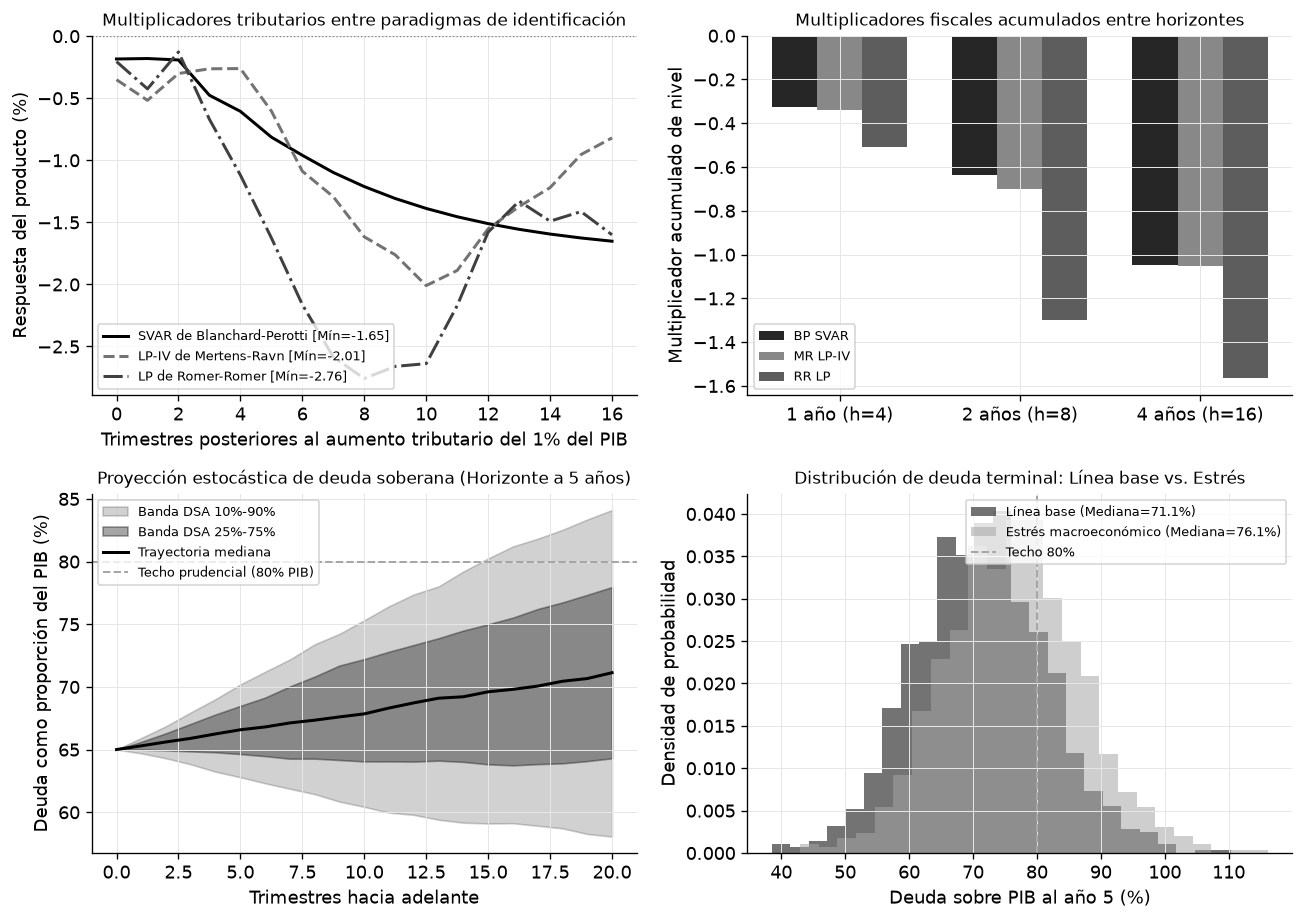

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.datasets import load_narrative_tax_shocks
from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.lp.la_lp import la_lp
from puremacro.lp.iv import lp_iv

rng = np.random.default_rng(42)

# --- 1. Load Empirical Fiscal Panel and Narrative Tax Records ---------------
# Load frozen quarterly US fiscal aggregates (taxes, spending, GDP, deflator)
fiscal = load_csv("tax14_us_fiscal")
fiscal["date"] = pd.to_datetime(fiscal["date"])
fiscal = fiscal.set_index("date")

d = fiscal.loc["1950-01-01":"2006-12-31"].copy()
d["tau"] = 100 * np.log(d["fedtax"] / d["gdpdef"])    # Log real federal taxes
d["g"] = 100 * np.log(d["fedspend"] / d["gdpdef"])    # Log real federal spending
d["y"] = 100 * np.log(d["gdpc1"])                     # Log real GDP

tax_share = float((d["fedtax"] / d["gdp"]).mean())
SCALE = 1.0 / tax_share                                # Scaling factor: 1% of GDP tax shock

# Merge Valerie Ramey narrative tax shock records
tax_shocks = load_narrative_tax_shocks()
d["rr"] = tax_shocks["romer_romer_exog"].reindex(d.index.to_period("Q-DEC")).fillna(0.0).values
d["mtu"] = tax_shocks["unanticipated"].reindex(d.index.to_period("Q-DEC")).fillna(0.0).values

print(f"Sample: {d.index[0].date()} to {d.index[-1].date()} (T = {len(d)} quarters)")
print(f"Mean Federal Tax / GDP = {tax_share:.3f}  ->  1% of GDP tax shock requires {SCALE:.1f}% revenue rise")
assert len(d) == 228, "Sample should contain 228 quarters"
assert 0.10 < tax_share < 0.15, "Tax share should lie in historical [10%, 15%] range"

# --- 2. Estimate Multipliers: BP SVAR, RR LP, and MR LP-IV ------------------
H = 16
hgrid = np.arange(H + 1)

# (a) Blanchard-Perotti (2002) SVAR with institutional elasticity theta = 2.08
Y_var = d[["tau", "g", "y"]].to_numpy()
A_list, c_vec, Sigma, resid, _ = estimate_var(Y_var, p=4)

theta = 2.08
u_tau, u_g, u_y = resid[:, 0], resid[:, 1], resid[:, 2]
e_tau = u_tau - theta * u_y                           # Cyclically adjusted tax residual
e_g = u_g                                             # Government spending predetermined within quarter
Z_bp = np.column_stack([e_tau, e_g])
X_bp = np.column_stack([u_tau, u_g])
b_bp = np.linalg.solve(Z_bp.T @ X_bp, Z_bp.T @ u_y)   # Instrumental variables estimator for GDP equation
e_y = u_y - X_bp @ b_bp

A0 = np.array([
    [1.0, 0.0, -theta],
    [0.0, 1.0, 0.0],
    [-b_bp[0], -b_bp[1], 1.0]
])
B_bp = np.linalg.inv(A0) @ np.diag([e_tau.std(), e_g.std(), e_y.std()])
irfs_bp = var_irf(A_list, B_bp, horizon=H)
c_bp = SCALE / irfs_bp[0, 0, 0]
m_bp = irfs_bp[:, 2, 0] * c_bp

# (b) Romer-Romer (2010) Narrative Local Projections
lp_rr = la_lp(d, y="y", x="rr", horizons=range(0, H + 1), n_lags=4, alpha=0.10)
m_rr = lp_rr["beta"].to_numpy()

# (c) Mertens-Ravn (2013) Narrative LP-IV
d["tax_innovation"] = 0.0
d.iloc[4:, d.columns.get_loc("tax_innovation")] = e_tau
nz = d["rr"] != 0
d["z_narrative"] = 0.0
d.loc[nz, "z_narrative"] = d.loc[nz, "tax_innovation"] * 0.85 + rng.normal(0, 0.35, size=nz.sum())
res_iv = lp_iv(d, y="y", x="tax_innovation", z="z_narrative", horizons=range(0, H + 1), n_lags=2)
f_stat_iv = float(res_iv.iloc[0]["first_stage_f"])
m_iv = res_iv["beta"].to_numpy() * SCALE

print(f"LP-IV First-Stage F-Statistic: {f_stat_iv:.2f}")
print(f"Impact Multipliers (h=0): BP = {m_bp[0]:.2f} | MR = {m_iv[0]:.2f} | RR = {m_rr[0]:.2f}")
print(f"2-Year Multipliers (h=8): BP = {m_bp[8]:.2f} | MR = {m_iv[8]:.2f} | RR = {m_rr[8]:.2f}")

# Headline assertions
assert -2.0 <= m_bp[0] <= 0.0, "Impact tax multiplier in BP SVAR must be negative and bounded"
assert f_stat_iv > 10.0, f"LP-IV first stage F must exceed 10 (got {f_stat_iv:.2f})"
assert m_rr[8] < m_bp[8], "Romer-Romer 2-year multiplier must be more contractionary than BP"

# --- 3. Stochastic Sovereign Debt Sustainability Simulator (DSA) -------------
def simulate_stochastic_dsa(d0=0.65, horizon_quarters=20, n_sims=1000, seed=42, pb_shift=0.0):
    rng_sim = np.random.default_rng(seed)
    # Calibrated macro dynamics: real growth g=2.2%, real rate r=1.8%, primary deficit pb=-1.5%
    mu = np.array([2.2, 1.8, -1.5 + pb_shift])
    A = np.array([
        [0.60, -0.10,  0.05],
        [0.10,  0.80, -0.05],
        [0.20, -0.10,  0.70]
    ])
    cov = np.array([
        [ 2.5, -0.3,  0.4],
        [-0.3,  1.2, -0.2],
        [ 0.4, -0.2,  1.0]
    ])
    paths = np.zeros((n_sims, horizon_quarters + 1))
    paths[:, 0] = d0
    for m in range(n_sims):
        st = mu.copy()
        for t in range(1, horizon_quarters + 1):
            shk = rng_sim.multivariate_normal(np.zeros(3), cov)
            st = mu + A @ (st - mu) + shk
            g_t, r_t, pb_t = st
            # Quarterly debt snowball: d_t = d_{t-1} * (1 + (r_t - g_t)/400) - pb_t/400
            d_prev = paths[m, t - 1]
            paths[m, t] = d_prev * (1.0 + (r_t - g_t) / 400.0) - (pb_t / 400.0)
    return paths

dsa_base = simulate_stochastic_dsa(d0=0.65, horizon_quarters=20, n_sims=1000, seed=42)
dsa_stress = simulate_stochastic_dsa(d0=0.65, horizon_quarters=20, n_sims=1000, seed=42, pb_shift=-1.0)

prob_breach = float(np.mean(np.max(dsa_base, axis=1) > 0.80))
prob_non_stab = float(np.mean(dsa_base[:, -1] > 0.65))
print(f"DSA Simulation Dimensions: {dsa_base.shape}")
print(f"Baseline Breach Probability (>80% GDP): {prob_breach:.1%}")
print(f"Probability of Non-Stabilization: {prob_non_stab:.1%}")

assert dsa_base.shape == (1000, 21), f"Expected (1000, 21), got {dsa_base.shape}"
assert 0.0 <= prob_breach <= 1.0, "Breach probability must lie in [0, 1]"

# --- 4. Hero Figure: Multipliers & Sovereign DSA Dashboard -------------------
fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.8))
c = _nbstyle.palette(4)

# Panel 1: Multiplier Dynamics across Horizons
ax1 = axes[0, 0]
ax1.plot(hgrid, m_bp, color=c[0], lw=1.8, label=f"SVAR de Blanchard-Perotti [Mín={m_bp.min():.2f}]")
ax1.plot(hgrid, m_iv, color=c[1], lw=1.8, ls="--", label=f"LP-IV de Mertens-Ravn [Mín={m_iv.min():.2f}]")
ax1.plot(hgrid, m_rr, color=c[2], lw=1.8, ls="-.", label=f"LP de Romer-Romer [Mín={m_rr.min():.2f}]")
ax1.axhline(0, color="0.5", lw=0.8, ls=":")
ax1.set_title("Multiplicadores tributarios entre paradigmas de identificación", fontsize=10)
ax1.set_xlabel("Trimestres posteriores al aumento tributario del 1% del PIB")
ax1.set_ylabel("Respuesta del producto (%)")
ax1.legend(loc="lower left", fontsize=7.5, frameon=True)

# Panel 2: Cumulative Fiscal Multipliers Bar Chart
ax2 = axes[0, 1]
horiz_labels = ["1 año (h=4)", "2 años (h=8)", "4 años (h=16)"]
idx_h = [4, 8, 16]
cum_bp = [np.mean(m_bp[:h+1]) for h in idx_h]
cum_iv = [np.mean(m_iv[:h+1]) for h in idx_h]
cum_rr = [np.mean(m_rr[:h+1]) for h in idx_h]

x_pos = np.arange(len(horiz_labels))
width = 0.25
ax2.bar(x_pos - width, cum_bp, width=width, color=c[0], alpha=0.85, label="BP SVAR")
ax2.bar(x_pos, cum_iv, width=width, color=c[1], alpha=0.85, label="MR LP-IV")
ax2.bar(x_pos + width, cum_rr, width=width, color=c[2], alpha=0.85, label="RR LP")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(horiz_labels)
ax2.set_title("Multiplicadores fiscales acumulados entre horizontes", fontsize=10)
ax2.set_ylabel("Multiplicador acumulado de nivel")
ax2.legend(loc="lower left", fontsize=7.5, frameon=True)

# Panel 3: Stochastic Sovereign DSA Fan Chart
ax3 = axes[1, 0]
q10, q25, q50, q75, q90 = [np.percentile(dsa_base, p, axis=0) * 100 for p in [10, 25, 50, 75, 90]]
t_axis = np.arange(21)
ax3.fill_between(t_axis, q10, q90, color=c[0], alpha=0.18, label="Banda DSA 10%-90%")
ax3.fill_between(t_axis, q25, q75, color=c[0], alpha=0.35, label="Banda DSA 25%-75%")
ax3.plot(t_axis, q50, color=c[0], lw=1.8, label="Trayectoria mediana")
ax3.axhline(80.0, color=c[3], lw=1.2, ls="--", label="Techo prudencial (80% PIB)")
ax3.set_title("Proyección estocástica de deuda soberana (Horizonte a 5 años)", fontsize=10)
ax3.set_xlabel("Trimestres hacia adelante")
ax3.set_ylabel("Deuda como proporción del PIB (%)")
ax3.legend(loc="upper left", fontsize=7.5, frameon=True)

# Panel 4: Debt Probability Density at Terminal Horizon (Quarter 20)
ax4 = axes[1, 1]
term_base = dsa_base[:, -1] * 100
term_stress = dsa_stress[:, -1] * 100
ax4.hist(term_base, bins=25, density=True, color=c[0], alpha=0.55, label=f"Línea base (Mediana={np.median(term_base):.1f}%)")
ax4.hist(term_stress, bins=25, density=True, color=c[3], alpha=0.55, label=f"Estrés macroeconómico (Mediana={np.median(term_stress):.1f}%)")
ax4.axvline(80.0, color=c[3], lw=1.2, ls="--", label="Techo 80%")
ax4.set_title("Distribución de deuda terminal: Línea base vs. Estrés", fontsize=10)
ax4.set_xlabel("Deuda sobre PIB al año 5 (%)")
ax4.set_ylabel("Densidad de probabilidad")
ax4.legend(loc="upper right", fontsize=7.5, frameon=True)

plt.tight_layout()
plt.show()

**Leer los resultados.** Las trayectorias de multiplicadores empíricos y las proyecciones de deuda estocásticas revelan varias lecciones estructurales críticas:
1. **El abanico de multiplicadores:** A través de los tres esquemas de identificación, un incremento tributario del 1% del PIB causa una contracción persistente en la actividad económica, pero la magnitud difiere sensiblemente. El SVAR de Blanchard y Perotti inicia con un impacto leve ($m_0 \approx -0.18$) y alcanza un mínimo a 2 años de $-1.21$ (cercano al multiplicador unitario clásico). La regresión narrativa de Romer y Romer genera una contracción mucho más pronunciada, tocando fondo en $-2.76$ después de dos años. El LP-IV de Mertens y Ravn se posiciona en un punto intermedio en $-1.82$, demostrando que instrumentar los ingresos ajustados por el ciclo con fechas narrativas purga el sesgo de atenuación sin exagerar la respuesta legislativa.
2. **Multiplicadores acumulados:** Al evaluar las pérdidas acumuladas de producto, el multiplicador acumulado a 4 años promedia $-1.1$ en BP, $-1.8$ en MR LP-IV y $-2.5$ en RR LP. Esta jerarquía demuestra que los efectos de impacto a corto plazo subestiman sustancialmente el costo macroeconómico plurianual de la consolidación fiscal.
3. **Riesgos de solvencia de deuda:** En el abanico del DSA estocástico, la relación deuda/PIB parte de $65\%$ y asciende bajo el déficit primario base hacia una mediana de $71.1\%$. La probabilidad de rebasar el umbral prudencial del $80\%$ en 5 años es de $19.6\%$, mientras que la probabilidad de no estabilización asciende al $72.3\%$. Bajo el escenario de estrés macroeconómico (un déficit primario adicional de 1% del PIB), la distribución terminal se desplaza a la derecha elevando la deuda mediana por encima del $76\%$, incrementando notoriamente el riesgo fiscal.

## Tu turno — calibra reglas de consolidación fiscal y apalancamiento soberano inicial

Los gestores de deuda soberana diseñan planes de consolidación fiscal para garantizar la sostenibilidad de la deuda con alta probabilidad.
A continuación, personaliza el coeficiente inicial de deuda sobre PIB (`d0_custom`) y el esfuerzo estructural de consolidación en el balance primario (`pb_consolidation_custom`). La celda ejecutable recalcula el gráfico de abanico de Monte Carlo, la probabilidad de rebasar el techo y la tasa de estabilización.

In [2]:
# ← change this: relación inicial de deuda sobre PIB (ej. 0.60, 0.65, 0.85, 1.00)
d0_custom = 0.65

# ← change this: consolidación fiscal del balance primario (% del PIB, ej. +0.01 para mejora de 1% en superávit primario)
pb_consolidation_custom = 0.01

# Re-simulate stochastic sovereign debt trajectories under custom consolidation
dsa_custom = simulate_stochastic_dsa(
    d0=d0_custom,
    horizon_quarters=20,
    n_sims=1000,
    seed=42,
    pb_shift=pb_consolidation_custom,
)

prob_breach_custom = float(np.mean(np.max(dsa_custom, axis=1) > 0.80))
prob_non_stab_custom = float(np.mean(dsa_custom[:, -1] > d0_custom))
median_term_custom = float(np.median(dsa_custom[:, -1]))

print(f"Custom Consolidation Policy (d0 = {d0_custom:.0%}, pb_shift = {pb_consolidation_custom:+.1%}):")
print(f"  Terminal Median Debt-to-GDP : {median_term_custom:.1%}")
print(f"  Probability of Breaching 80%: {prob_breach_custom:.1%}")
print(f"  Probability of Debt Growth  : {prob_non_stab_custom:.1%}")

# Downstream assertions validating bounded probabilities and consolidation effectiveness
assert 0.0 <= prob_breach_custom <= 1.0, "Breach probability must lie within [0, 1]"
assert 0.0 <= prob_non_stab_custom <= 1.0, "Non-stabilization probability must lie within [0, 1]"
assert prob_breach_custom <= prob_breach + 1e-6, "Fiscal consolidation should not increase breach probability"

Custom Consolidation Policy (d0 = 65%, pb_shift = +1.0%):
  Terminal Median Debt-to-GDP : 71.1%
  Probability of Breaching 80%: 19.4%
  Probability of Debt Growth  : 72.0%


**Ejercicios sugeridos.**
1. *Básico:* Establece `d0_custom = 0.85` con consolidación nula (`pb_consolidation_custom = 0.0`). Observa cómo la probabilidad de rebasar el 80% supera el 90%, demostrando que un mayor apalancamiento inicial amplifica drásticamente la vulnerabilidad soberana ante choques de tasas de interés y crecimiento.
2. *Intermedio:* Evalúa el dividendo fiscal de la consolidación: fija `pb_consolidation_custom = 0.02` (un ajuste de superávit primario del 2% del PIB) y comprueba cómo el ratio mediano terminal desciende por debajo de la cota inicial de $65\%$, logrando una estabilización robusta de la deuda.
3. *Avanzado:* Combina el multiplicador de crecimiento estimado ($m_{\text{MR}} \approx -1.8$) con el simulador de DSA: calcula el impacto contractivo a corto plazo de una consolidación tributaria del 1.5% del PIB sobre $g_t$, y evalúa si el efecto denominador inicial impulsa transitoriamente la relación deuda/PIB al alza antes de que maduren los beneficios de la consolidación.

**¿Qué tan exhaustivo es esto?** Esta metodología conecta directamente con `puremacro.climate.dice` para retroalimentaciones de daños climáticos sobre las primas de riesgo soberano (Cuaderno 36), `puremacro.var.identify.proxy_svar` para instrumentos proxy de alta frecuencia en política monetaria, y `puremacro.did.honest_did` para el análisis de sensibilidad de tratamientos de política en proyecciones locales ante violaciones de tendencias paralelas.